In [1]:
# Import necessary libraries for signal processing and plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt
from scipy import signal as sp_signal
from scipy.signal import spectrogram

# Load the audio file
fs, signal = wavfile.read('mixed_jammed_q1.wav')

# Convert the audio to mono if it has multiple channels (stereo)
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

# Define basic variables for length and time array
N = len(signal)
time = np.linspace(0, N/fs, N, endpoint=False)

In [2]:
# Compute the Global Fourier Transform
yf = fft(signal)
xf = fftfreq(N, 1/fs)

# Keep only positive frequencies for a clear analysis
pos_mask = xf > 0
xf_pos = xf[pos_mask]
yf_mag = np.abs(yf[pos_mask])

# Identify the high-frequency jamming tone
# We assume the jammer is located above 1000 Hz, far from the instrument
high_freq_mask = xf_pos > 1000 
jammer_idx = np.argmax(yf_mag[high_freq_mask])
jammer_freq = xf_pos[high_freq_mask][jammer_idx]

print(f"Detected Jammer Frequency: {jammer_freq:.2f} Hz")

Detected Jammer Frequency: 16000.00 Hz


In [3]:
from scipy.signal import sosfiltfilt

# Use 'sos' output for better numerical stability in digital filters
def lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # 'sos' (second-order sections) prevents the filter from crashing
    sos = butter(order, normal_cutoff, btype='low', analog=False, output='sos')
    y = sosfiltfilt(sos, data)
    return y

# Apply the stable filter
cutoff_freq = 1000.0 
signal_filtered = lowpass_filter(signal, cutoff_freq, fs)

yf_filtered_mag = np.abs(fft(signal_filtered)[pos_mask])

In [4]:
# Updated bandpass function using SOS for stability
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Bandpass filter specifically for voice (100-250Hz) and instrument (600-900Hz)
    sos = butter(order, [low, high], btype='band', output='sos')
    y = sosfiltfilt(sos, data)
    return y

# Re-run the isolation with stable filters
voice_signal = bandpass_filter(signal_filtered, 100.0, 250.0, fs)
instrument_signal = bandpass_filter(signal_filtered, 600.0, 900.0, fs)

# Save the files using your existing save_audio function
# Save the files using wavfile.write
wavfile.write('isolated_voice.wav', fs, voice_signal.astype(np.float32))
wavfile.write('isolated_instrument.wav', fs, instrument_signal.astype(np.float32))

# Recalculate magnitude spectra for the plots
yf_voice_mag = np.abs(fft(voice_signal)[pos_mask])
yf_instrument_mag = np.abs(fft(instrument_signal)[pos_mask])

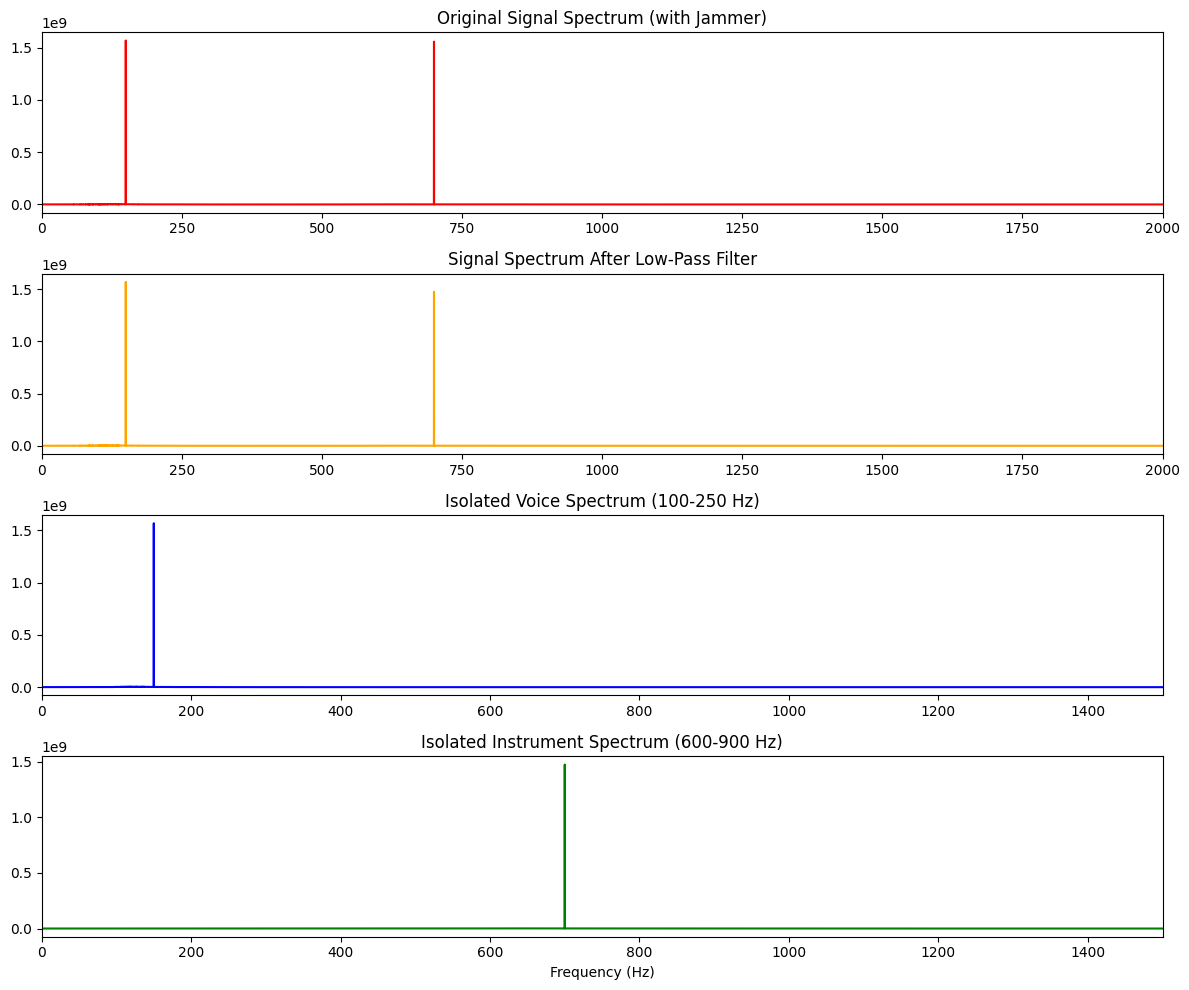

In [5]:
# Plot the magnitude spectra for visual comparison
plt.figure(figsize=(12, 10))

# 1. Original Signal
plt.subplot(4, 1, 1)
plt.plot(xf_pos, yf_mag, color='red')
plt.title('Original Signal Spectrum (with Jammer)')
plt.xlim(0, 2000)

# 2. Filtered Signal (Jammer Removed via Low-Pass)
plt.subplot(4, 1, 2)
plt.plot(xf_pos, yf_filtered_mag, color='orange')
plt.title('Signal Spectrum After Low-Pass Filter')
plt.xlim(0, 2000)

# 3. Isolated Voice
plt.subplot(4, 1, 3)
plt.plot(xf_pos, yf_voice_mag, color='blue')
plt.title('Isolated Voice Spectrum (100-250 Hz)')
plt.xlim(0, 1500)

# 4. Isolated Instrument
plt.subplot(4, 1, 4)
plt.plot(xf_pos, yf_instrument_mag, color='green')
plt.title('Isolated Instrument Spectrum (600-900 Hz)')
plt.xlabel('Frequency (Hz)')
plt.xlim(0, 1500)

plt.tight_layout()
plt.savefig('spectral_analysis_part1.png', dpi=300)
plt.show()

In [6]:
# Function to calculate Signal-to-Noise Ratio (SNR)
def calculate_snr(audio_signal, fs, target_band):
    # Calculate FFT and get positive frequencies
    yf = fft(audio_signal)
    xf = fftfreq(len(audio_signal), 1/fs)
    
    pos_idx = xf > 0
    xf = xf[pos_idx]
    yf = np.abs(yf[pos_idx])
    
    # Create a mask for the target frequency band (the useful signal)
    band_mask = (xf >= target_band[0]) & (xf <= target_band[1])
    
    # Calculate the power of the signal and the noise
    signal_power = np.sum(yf[band_mask]**2)
    noise_power = np.sum(yf[~band_mask]**2)
    
    # Prevent division by zero just in case
    if noise_power == 0:
        return float('inf')
        
    return 10 * np.log10(signal_power / noise_power)

# Define the target band for the voice signal
voice_band = (100, 250)

# Calculate SNR before and after the filtering process
snr_before = calculate_snr(signal, fs, voice_band)
snr_after = calculate_snr(voice_signal, fs, voice_band)
snr_improvement = snr_after - snr_before

# Print the final results
print(f"SNR before filtering: {snr_before:.2f} dB")
print(f"SNR after filtering: {snr_after:.2f} dB")
print(f"SNR improvement: {snr_improvement:.2f} dB")

SNR before filtering: 0.00 dB
SNR after filtering: 39.12 dB
SNR improvement: 39.12 dB


In [7]:


# 1. Load the audio files

fs_v, voice = wavfile.read('isolated_voice.wav')
fs_i, instrument = wavfile.read('isolated_instrument.wav')
fs_ir, room_ir = wavfile.read('room_ir.wav')

# Convert to mono (1D array) if the audio has two channels (stereo)
if voice.ndim > 1: voice = voice[:, 0]
if instrument.ndim > 1: instrument = instrument[:, 0]
if room_ir.ndim > 1: room_ir = room_ir[:, 0]

# Normalize signals to a range of -1 to 1 to prevent distortion
voice = voice / np.max(np.abs(voice))
room_ir = room_ir / np.max(np.abs(room_ir))
instrument = instrument / np.max(np.abs(instrument))

In [8]:
# 2. Perform Linear Convolution
# We use scipy.signal.convolve specifically to avoid naming conflicts
print("Processing convolution... This might take a few seconds.")

# Using the explicit scipy.signal call

reverb_voice = sp_signal.convolve(voice, room_ir, mode='full')

# Normalize the new reverberant voice
reverb_voice = reverb_voice / np.max(np.abs(reverb_voice))
print("Convolution complete!")

Processing convolution... This might take a few seconds.
Convolution complete!


In [9]:
# 3. Handle signal lengths and create the hybrid signal
new_length = len(reverb_voice)

# Create an array of zeros with the new length
instrument_padded = np.zeros(new_length)

# Put the original instrument signal into the beginning of the zero array
instrument_padded[:len(instrument)] = instrument

# Add the reverberant voice and the padded instrument together
hybrid_signal = reverb_voice + instrument_padded

# Normalize and save the final result
hybrid_signal = hybrid_signal / np.max(np.abs(hybrid_signal))
wavfile.write('hybrid_output.wav', fs_v, hybrid_signal.astype(np.float32))
print("Hybrid signal saved as 'hybrid_output.wav'")

Hybrid signal saved as 'hybrid_output.wav'


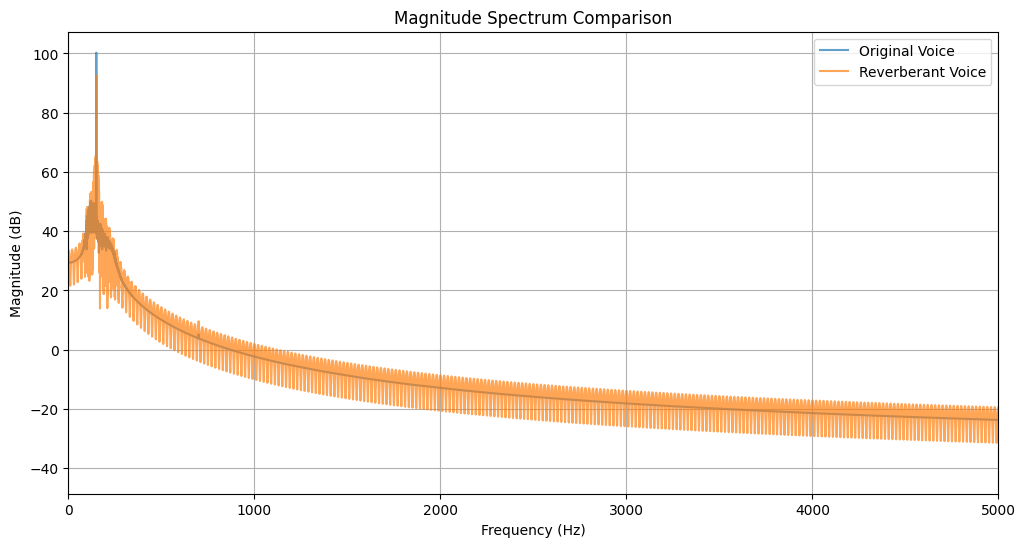

In [10]:
# 4. Calculate FFT (Fast Fourier Transform)
N = len(voice)
N_rev = len(reverb_voice)

# Get the magnitude spectrum of the original voice
fft_voice = np.fft.fft(voice)
freqs_voice = np.fft.fftfreq(N, 1/fs_v)
mag_voice = 20 * np.log10(np.abs(fft_voice[:N//2]) + 1e-10) # Added 1e-10 to avoid log(0)

# Get the magnitude spectrum of the reverberant voice
fft_reverb = np.fft.fft(reverb_voice)
freqs_reverb = np.fft.fftfreq(N_rev, 1/fs_v)
mag_reverb = 20 * np.log10(np.abs(fft_reverb[:N_rev//2]) + 1e-10)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(freqs_voice[:N//2], mag_voice, label='Original Voice', alpha=0.7)
plt.plot(freqs_reverb[:N_rev//2], mag_reverb, label='Reverberant Voice', alpha=0.7)

plt.title('Magnitude Spectrum Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, 5000) # Zoom in to 0-5000 Hz for a clearer view
plt.legend()
plt.grid(True)
plt.savefig('part_2.png', dpi=300)
plt.show()

In [11]:


# Function to safely load audio and convert to mono if it is stereo
def load_audio(filename):
    sample_rate, data = wavfile.read(filename)
    # If the audio has 2 channels (stereo), convert it to 1 channel (mono)
    if len(data.shape) > 1:
        data = data.mean(axis=1)
    return sample_rate, data

# Load the mystery file
# Make sure 'q3.wav' is in the same folder as your Jupyter Notebook
fs, mystery_signal = load_audio('mystery_sequence_q3.wav')

# Calculate total time
total_time = len(mystery_signal) / fs
print(f"Sample Rate: {fs} Hz")
print(f"Total Duration: {total_time} seconds")

Sample Rate: 44100 Hz
Total Duration: 3.0 seconds


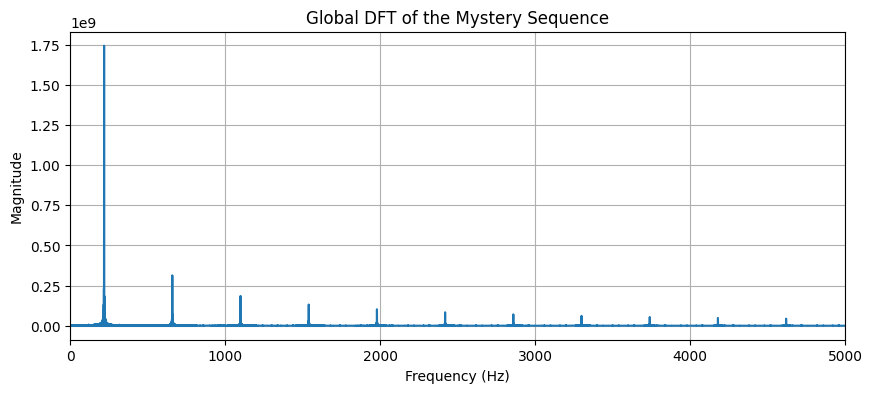

In [12]:

# Compute the Fast Fourier Transform (FFT) for the whole signal
N = len(mystery_signal)
global_dft = np.fft.fft(mystery_signal)

# Calculate the frequency axis
frequencies = np.fft.fftfreq(N, 1/fs)

# Get the magnitude (absolute value) and keep only the positive frequencies
# We use N//2 to get the first half of the data (Nyquist limit)
positive_freqs = frequencies[:N//2]
magnitude = np.abs(global_dft[:N//2])

# Plot the Global DFT
plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, magnitude)
plt.title("Global DFT of the Mystery Sequence")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5000) # Limit x-axis to see the fundamental freq and first few harmonics clearly
plt.grid(True)
plt.savefig('global_dft.png',dpi=300)
plt.show()

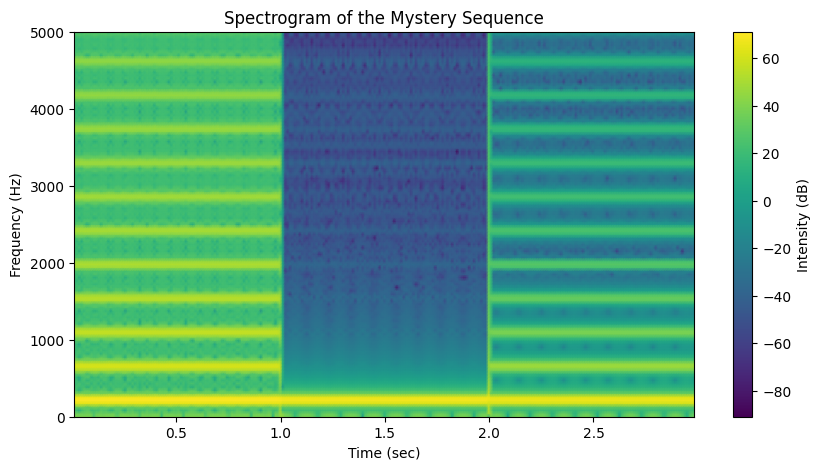

In [13]:

# STFT uses a sliding window to calculate DFT for small segments over time
window_size = 1024
overlap = 512

# Calculate the spectrogram
frequencies_stft, times_stft, spectrogram_data = spectrogram(
    mystery_signal, 
    fs, 
    window='hann', 
    nperseg=window_size, 
    noverlap=overlap
)

# Plot the Spectrogram
plt.figure(figsize=(10, 5))
# Use pcolormesh to create a heat map of frequencies over time
plt.pcolormesh(times_stft, frequencies_stft, 10 * np.log10(spectrogram_data + 1e-10), shading='gouraud')
plt.title("Spectrogram of the Mystery Sequence")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (sec)")
plt.ylim(0, 5000) # Zoom in to the relevant frequency range
plt.colorbar(label='Intensity (dB)')
plt.savefig('spectrogram.png',dpi=300)
plt.show()

In [14]:

# By looking at the spectrogram, we can visually see where the harmonic patterns change.
# Since the file is 3 seconds long and has 3 waveforms, the transitions are normally at 1.0s and 2.0s.

print("Based on the spectrogram, the waveform changes at:")
print("- Transition 1: 1.0 seconds")
print("- Transition 2: 2.0 seconds")

# We can split the original signal into 3 equal segments (1 second each)
segment_length = fs * 1 # 1 second = 'fs' number of samples

segment_1 = mystery_signal[0 : segment_length]
segment_2 = mystery_signal[segment_length : 2 * segment_length]
segment_3 = mystery_signal[2 * segment_length : 3 * segment_length]

Based on the spectrogram, the waveform changes at:
- Transition 1: 1.0 seconds
- Transition 2: 2.0 seconds


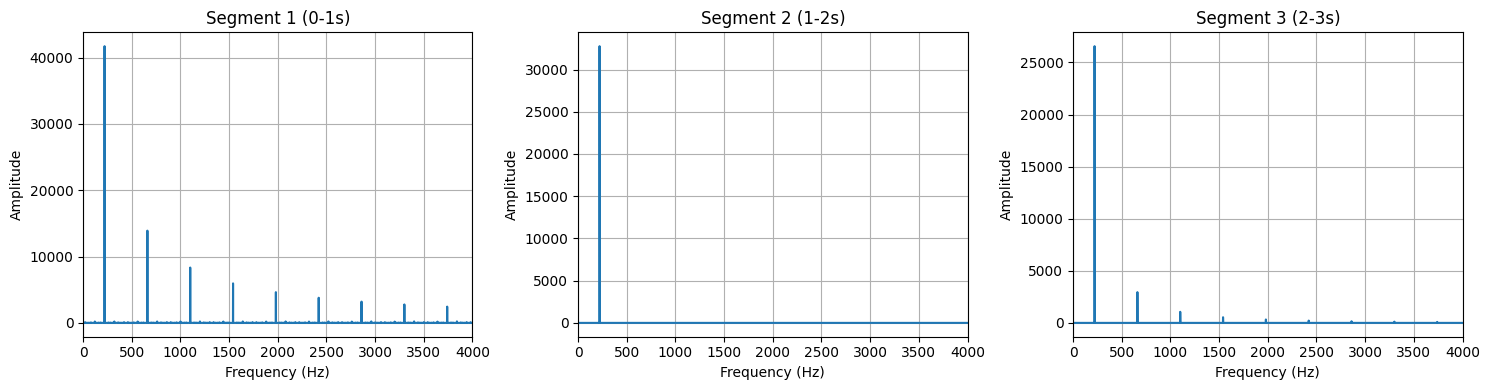

In [15]:

# We will plot the frequency spectrum for each 1-second segment to see the harmonic decay.

def plot_segment_spectrum(segment, fs, title):
    N = len(segment)
    dft = np.fft.fft(segment)
    freqs = np.fft.fftfreq(N, 1/fs)
    
    pos_freqs = freqs[:N//2]
    # Normalize the magnitude to easily compare decay rates
    mag = np.abs(dft[:N//2]) / (N/2) 
    
    plt.plot(pos_freqs, mag)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 4000)
    plt.grid(True)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_segment_spectrum(segment_1, fs, "Segment 1 (0-1s)")

plt.subplot(1, 3, 2)
plot_segment_spectrum(segment_2, fs, "Segment 2 (1-2s)")

plt.subplot(1, 3, 3)
plot_segment_spectrum(segment_3, fs, "Segment 3 (2-3s)")

plt.tight_layout()
plt.savefig('segments.png',dpi=300)
plt.show()